🚀 FLOW DATA SCIENCE

🔹 1️⃣ Import Library

- pandas
- numpy
- matplotlib
- seaborn
- sklearn

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

🔹 2️⃣ Load Data
- read_csv()
- head()
- info()
- describe()

In [7]:
df = pd.read_csv('cc.csv')
df.head()

,CustomerID,Age,Gender,MonthlyCharge,ContractType,InternetService,Tenure,Churn
0,1,56,Male,621923,Month-to-month,Fiber,6,Yes
1,2,46,Female,649384,Two year,Fiber,56,Yes
2,3,32,Male,358099,Month-to-month,DSL,19,No
3,4,25,Male,257561,One year,Fiber,37,Yes
4,5,38,Male,717010,Month-to-month,Fiber,58,No


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       500 non-null    int64
 1   Age              500 non-null    int64
 2   Gender           500 non-null    str  
 3   MonthlyCharge    500 non-null    int64
 4   ContractType     500 non-null    str  
 5   InternetService  500 non-null    str  
 6   Tenure           500 non-null    int64
 7   Churn            500 non-null    str  
dtypes: int64(4), str(4)
memory usage: 31.4 KB


In [9]:
df.describe()

,CustomerID,Age,MonthlyCharge,Tenure
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,39.326000,497803.544000,30.392000
std,144.481833,12.200386,145099.235269,17.169972
min,1.000000,18.000000,250126.000000,1.000000
25%,125.750000,29.000000,375789.000000,16.000000
50%,250.500000,41.000000,502797.500000,30.000000
75%,375.250000,50.000000,628442.000000,46.000000
max,500.000000,59.000000,749876.000000,59.000000


🔹 3️⃣ Data Understanding
- Cek tipe data
- Identifikasi target
- Bedakan numerical & categorical
- Cek missing value
- Cek duplikasi

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       500 non-null    int64
 1   Age              500 non-null    int64
 2   Gender           500 non-null    str  
 3   MonthlyCharge    500 non-null    int64
 4   ContractType     500 non-null    str  
 5   InternetService  500 non-null    str  
 6   Tenure           500 non-null    int64
 7   Churn            500 non-null    str  
dtypes: int64(4), str(4)
memory usage: 31.4 KB


In [11]:
df_cat = df.select_dtypes(include=['object','category'])
df_cat_info = pd.DataFrame({
    'Column_Name': df_cat.columns,
    'Data_Type': df_cat.dtypes.values
})
df_cat_info

C:\Users\ACER\AppData\Local\Temp\ipykernel_10836\3760681561.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = df.select_dtypes(include=['object','category'])


,Column_Name,Data_Type
0,Gender,str
1,ContractType,str
2,InternetService,str
3,Churn,str


In [60]:
cat_cols = df.select_dtypes(include='number')
cat_cols = pd.DataFrame({
    'Column_Name': cat_cols.columns,
    'Data_Type': cat_cols.dtypes.values
})
cat_cols

,Column_Name,Data_Type
0,CustomerID,int64
1,Age,int64
2,Gender,int64
3,MonthlyCharge,int64
4,Tenure,int64
5,Churn,int64


In [30]:
df_miss_values = df.isnull().sum()
df_miss_values = pd.DataFrame({"Columns_Name": df_miss_values.index,
                               "Misssing_Values": df_miss_values.values})
df_miss_values

,Columns_Name,Misssing_Values
0,CustomerID,0
1,Age,0
2,Gender,0
3,MonthlyCharge,0
4,ContractType,0
5,InternetService,0
6,Tenure,0
7,Churn,0


In [41]:
df_duplicated = pd.DataFrame({
    "Columns_Name": df.columns,
    "Check_Duplicated": df.duplicated().sum()
})

df_duplicated

,Columns_Name,Check_Duplicated
0,CustomerID,0
1,Age,0
2,Gender,0
3,MonthlyCharge,0
4,ContractType,0
5,InternetService,0
6,Tenure,0
7,Churn,0


🔹 4️⃣ Data Cleaning
- Handling missing value (drop / fill)
- Encoding categorical (Label / One Hot)
- Outlier detection (IQR / Boxplot)
- Drop kolom tidak relevan

In [47]:
if df.isnull().sum().sum() == 0:
    print("Tidak ada data null lagi")
else:
    print("Masih ada data null")
    df.fillna(df.mean())

Tidak ada data null lagi


In [48]:
df.head()

,CustomerID,Age,Gender,MonthlyCharge,ContractType,InternetService,Tenure,Churn
0,1,56,Male,621923,Month-to-month,Fiber,6,Yes
1,2,46,Female,649384,Two year,Fiber,56,Yes
2,3,32,Male,358099,Month-to-month,DSL,19,No
3,4,25,Male,257561,One year,Fiber,37,Yes
4,5,38,Male,717010,Month-to-month,Fiber,58,No


In [49]:
from sklearn.preprocessing import LabelEncoder
Le = LabelEncoder()
df['Gender'] = Le.fit_transform(df['Gender'])
df['Churn'] = Le.fit_transform(df['Churn'])
df.head()

,CustomerID,Age,Gender,MonthlyCharge,ContractType,InternetService,Tenure,Churn
0,1,56,1,621923,Month-to-month,Fiber,6,1
1,2,46,0,649384,Two year,Fiber,56,1
2,3,32,1,358099,Month-to-month,DSL,19,0
3,4,25,1,257561,One year,Fiber,37,1
4,5,38,1,717010,Month-to-month,Fiber,58,0


In [50]:
Q1 = df['MonthlyCharge'].quantile(0.25)
Q3 = df['MonthlyCharge'].quantile(0.75)
IQR = Q3-Q1

In [51]:
lower_bount = Q1 - 1.5*IQR
upper_bount = Q3 + 1.5*IQR

In [52]:
outlier = df[
    ( df['MonthlyCharge'] < lower_bount) |
    ( df['MonthlyCharge'] > upper_bount)    
]

jumlah_outlier = outlier.shape[0]
jumlah_outlier

0

---

In [62]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    total_outlier = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"Jumlah outlier pada kolom {col} adalah {total_outlier}")

Jumlah outlier pada kolom CustomerID adalah 0
Jumlah outlier pada kolom Age adalah 0
Jumlah outlier pada kolom Gender adalah 0
Jumlah outlier pada kolom MonthlyCharge adalah 0
Jumlah outlier pada kolom Tenure adalah 0
Jumlah outlier pada kolom Churn adalah 0


<Axes: xlabel='MonthlyCharge'>

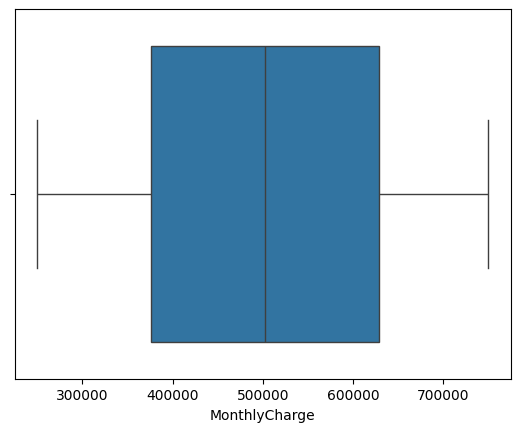

In [61]:
import seaborn as sns
sns.boxplot(x=df["MonthlyCharge"])

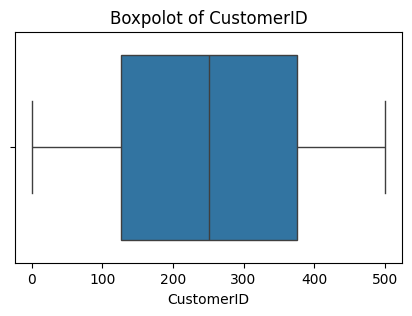

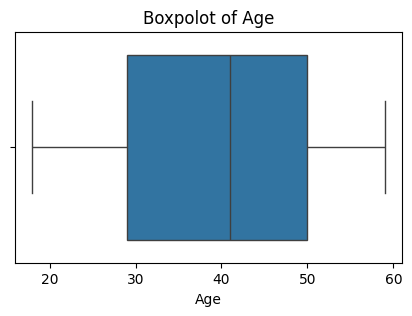

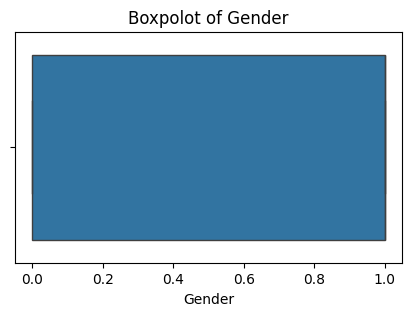

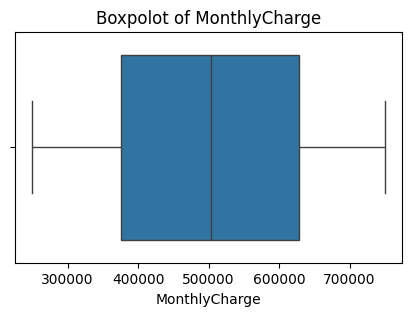

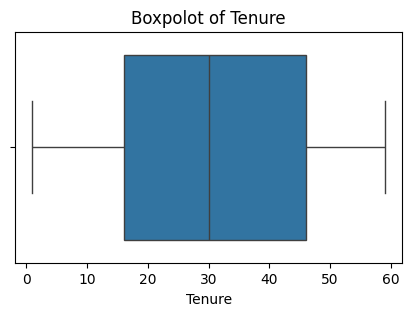

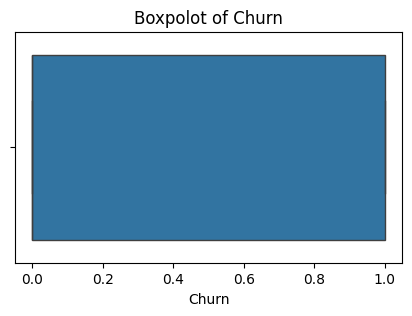

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

df_cols = df.select_dtypes(include='number').columns

for col in df_cols :
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxpolot of {col}")
    plt.show()

In [69]:
import numpy as np

df_cols = df.select_dtypes(include='number').columns

for col in df_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}")
    print(f"Jumlah outlier: {outliers.shape[0]}")
    print("-"*30)

CustomerID
Jumlah outlier: 0
------------------------------
Age
Jumlah outlier: 0
------------------------------
Gender
Jumlah outlier: 0
------------------------------
MonthlyCharge
Jumlah outlier: 0
------------------------------
Tenure
Jumlah outlier: 0
------------------------------
Churn
Jumlah outlier: 0
------------------------------


🔹 5️⃣ Exploratory Data Analysis (EDA)
- Distribusi target (countplot)
- Hubungan kategori vs target
- Distribusi numerik (histogram)
- Boxplot numerik vs target
- Heatmap korelasi

🔹 6️⃣ Feature & Target Split
- X = fitur
- y = target

🔹 7️⃣ Train Test Split
- Bagi data training & testing
- Gunakan random_state

🔹 8️⃣ Feature Scaling
- StandardScaler / MinMaxScaler
- Wajib untuk Logistic Regression & KNN

🔹 9️⃣ Modeling
- Untuk Classification:
- Logistic Regression
- Decision Tree
- Random Forest
- Untuk Regression:
- Linear Regression

🔹 🔟 Prediction
- model.predict()

🔹 1️⃣1️⃣ Evaluation
- Confusion Matrix
- - Classification:
- - - Accuracy
- - - Precision
- - - Recall
- - - F1-score

- - Regression:
- - - MAE
- - - MSE
- - - R2 Score

🔹 1️⃣2️⃣ Cross Validation

- cross_val_score()
- Cek overfitting

🎯 1️⃣ Kenapa Pilih Model Tersebut?
✅ Jika Logistic Regression

Saya memilih Logistic Regression karena model ini sederhana, cepat dilatih, mudah diinterpretasikan, dan cocok untuk masalah klasifikasi biner seperti churn. Selain itu, model ini memberikan probabilitas sehingga bisa digunakan untuk analisis risiko.

✅ Jika Decision Tree

Saya memilih Decision Tree karena mudah dipahami dan bisa menjelaskan pengambilan keputusan dalam bentuk aturan yang jelas.

✅ Jika Random Forest

Saya memilih Random Forest karena mampu mengurangi overfitting dan biasanya memiliki performa yang lebih stabil dibandingkan model tunggal seperti Decision Tree.

🎯 2️⃣ Kenapa Perlu Scaling?

Scaling diperlukan karena beberapa model seperti Logistic Regression dan KNN sensitif terhadap skala data. Jika fitur memiliki rentang nilai yang berbeda jauh, model bisa bias terhadap fitur dengan nilai besar. Scaling membuat semua fitur berada dalam skala yang sebanding.

Tambahan kuat:

Scaling membantu proses optimisasi menjadi lebih stabil dan cepat konvergen.

🎯 3️⃣ Kenapa Recall Lebih Penting dari Accuracy?

Dalam kasus churn:

Recall lebih penting karena kita ingin menangkap sebanyak mungkin pelanggan yang benar-benar akan churn. Jika model gagal mendeteksi mereka, perusahaan bisa kehilangan pelanggan dan pendapatan.

Contoh kuat:

Accuracy bisa tinggi walaupun model gagal mendeteksi churn, terutama jika data tidak seimbang. Oleh karena itu, recall lebih relevan terhadap dampak bisnis.

🎯 4️⃣ Apa Dampak Bisnisnya?

Jawaban strategis:

Model ini membantu perusahaan mengidentifikasi pelanggan berisiko churn sehingga tim marketing dapat memberikan promosi atau program retensi lebih awal. Dampaknya adalah menurunkan churn rate dan meningkatkan revenue retention.

Versi angka:

Jika churn turun 10%, maka perusahaan dapat menghemat biaya akuisisi pelanggan baru dan meningkatkan lifetime value pelanggan.

🎯 5️⃣ Jika Model Jelek, Apa yang Dilakukan?

Jawaban terstruktur:

Periksa data (missing value, outlier, imbalance)

Coba feature engineering tambahan

Gunakan teknik resampling (SMOTE jika imbalance)

Coba model lain

Lakukan hyperparameter tuning (GridSearchCV)

Tambah data jika memungkinkan

Jawaban profesional:

Jika performa model rendah, saya akan mengevaluasi kualitas data, melakukan feature engineering tambahan, mencoba model lain, dan melakukan hyperparameter tuning untuk meningkatkan performa.

🔥 Versi Jawaban Singkat 30 Detik (Siap Ujian)

Saya memilih Logistic Regression karena cocok untuk klasifikasi biner dan mudah diinterpretasikan. Scaling diperlukan agar model tidak bias terhadap fitur dengan skala besar. Dalam kasus churn, recall lebih penting karena kita ingin menangkap sebanyak mungkin pelanggan yang berpotensi berhenti. Dampak bisnisnya adalah penurunan churn dan peningkatan retensi pelanggan. Jika model kurang baik, saya akan evaluasi data, lakukan feature engineering, dan tuning model.